<a href="https://colab.research.google.com/github/bhupeshupadhayay6-cpu/EX1/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
#load titanic dataset
df = sns.load_dataset("titanic")


In [ ]:
# structure and dimentions
print("shape:",df.shape)
print("data types:")
print(df.dtypes)

shape: (891, 15)
data types:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


In [ ]:
# Descriptive statistics
print(" Descriptive statistics:")
print(df.describe(include="all"))


 Descriptive statistics:
          survived      pclass   sex         age       sibsp       parch  \
count   891.000000  891.000000   891  714.000000  891.000000  891.000000   
unique         NaN         NaN     2         NaN         NaN         NaN   
top            NaN         NaN  male         NaN         NaN         NaN   
freq           NaN         NaN   577         NaN         NaN         NaN   
mean      0.383838    2.308642   NaN   29.699118    0.523008    0.381594   
std       0.486592    0.836071   NaN   14.526497    1.102743    0.806057   
min       0.000000    1.000000   NaN    0.420000    0.000000    0.000000   
25%       0.000000    2.000000   NaN   20.125000    0.000000    0.000000   
50%       0.000000    3.000000   NaN   28.000000    0.000000    0.000000   
75%       1.000000    3.000000   NaN   38.000000    1.000000    0.000000   
max       1.000000    3.000000   NaN   80.000000    8.000000    6.000000   

              fare embarked  class  who adult_male deck  embar

In [ ]:
#numerical and categorical attributes
numeric_cols = df.select_dtypes(include="number").columns
categorical_cols =df.select_dtypes(exclude="number").columns
print("Numerical attributes:")
print(list(numeric_cols))
print("Categorical attributes:")
print(list(categorical_cols))


Numerical attributes:
['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical attributes:
['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [ ]:
#missing values
print("missing values:")
print(df.isnull().sum())

missing values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [ ]:
# mean,median, std, min, max
print("numerical summary:")
print(df[numeric_cols].agg(
    ["mean", "median", "std", "min", "max"]
).T)


numerical summary:
               mean   median        std   min       max
survived   0.383838   0.0000   0.486592  0.00    1.0000
pclass     2.308642   3.0000   0.836071  1.00    3.0000
age       29.699118  28.0000  14.526497  0.42   80.0000
sibsp      0.523008   0.0000   1.102743  0.00    8.0000
parch      0.381594   0.0000   0.806057  0.00    6.0000
fare      32.204208  14.4542  49.693429  0.00  512.3292


In [ ]:
# simple outlier detection using IQR

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[numeric_cols]< (Q1-1.5*IQR)) |
           (df[numeric_cols]> (Q3+1.5*IQR))).sum()
print("outliers:")
print(outliers)


outliers:
survived      0
pclass        0
age          11
sibsp        46
parch       213
fare        116
dtype: int64


In [ ]:
# Important Relationship
print("\n Survival rate by sex:")
print(df.groupby("sex",observed = True)["survived"].mean())

print("\n Survival rate by passenger class:")
print(df.groupby("pclass")["survived"].mean())



 Survival rate by sex:


NameError: name 'df' is not defined

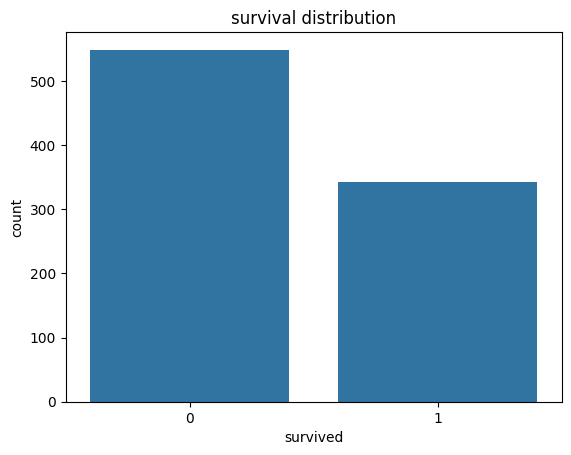

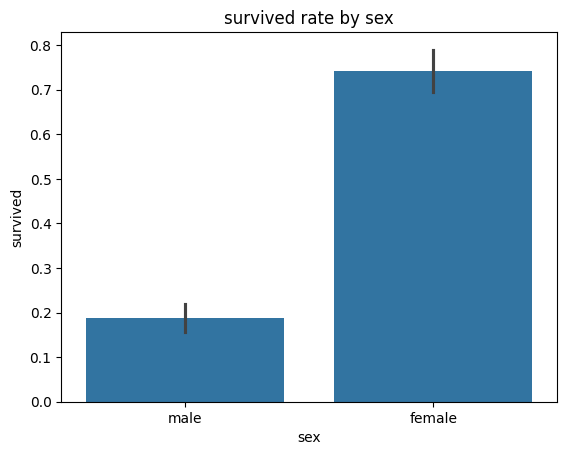

In [ ]:
# Visualization

sns.countplot(data=df, x="survived")
plt.title("survival distribution")
plt.show()

sns.barplot(data = df, x="sex", y="survived")
plt.title("survived rate by sex")
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
#load Iris dataset
df= sns.load_dataset("iris")


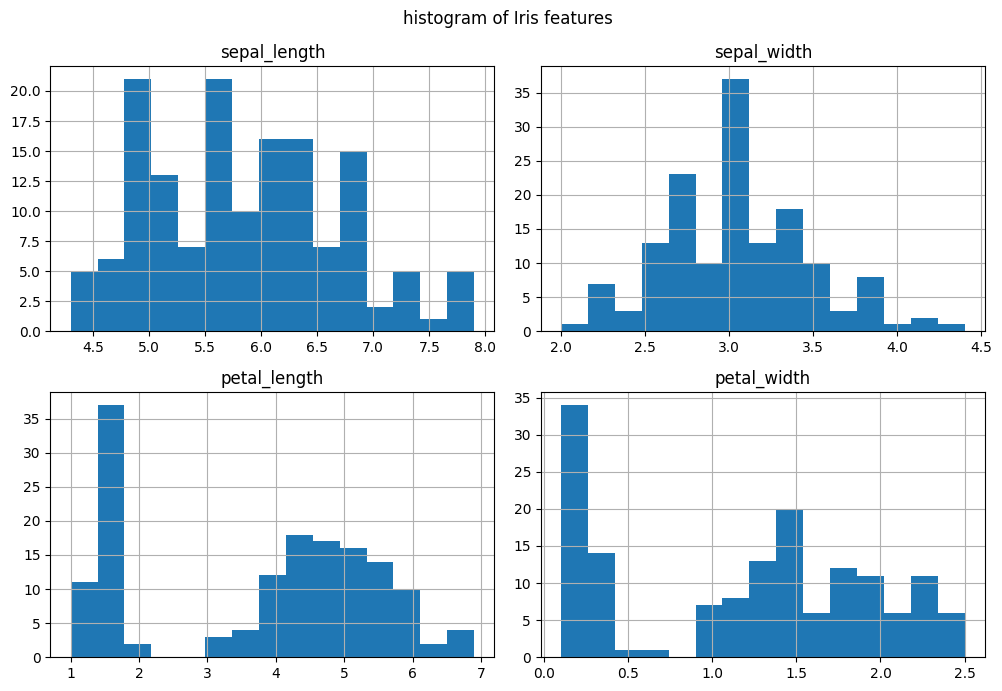

In [ ]:
#histogram
df.hist(figsize=(10,7),bins=15)
plt.suptitle("histogram of Iris features")
plt.tight_layout()
plt.show()

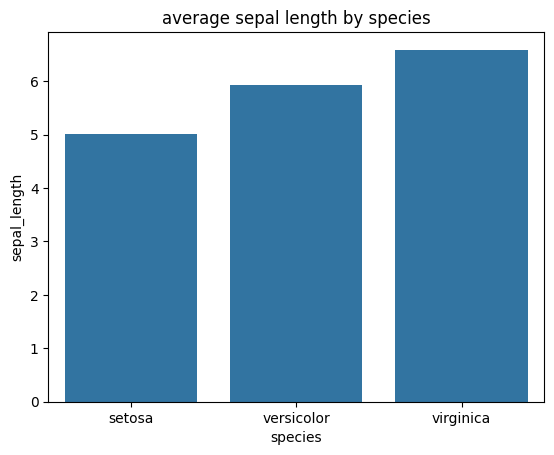

In [ ]:
#bar chart
sns.barplot(data=df, x="species", y="sepal_length", errorbar= None)
plt.title("average sepal length by species")
plt.show()

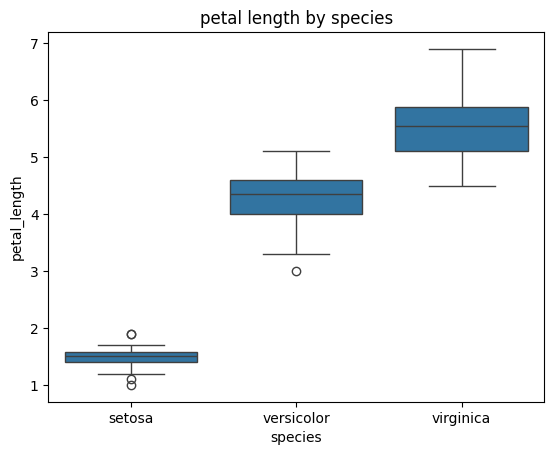

In [ ]:
#boxplot
sns.boxplot(data=df, x="species", y="petal_length")
plt.title("petal length by species")
plt.show()

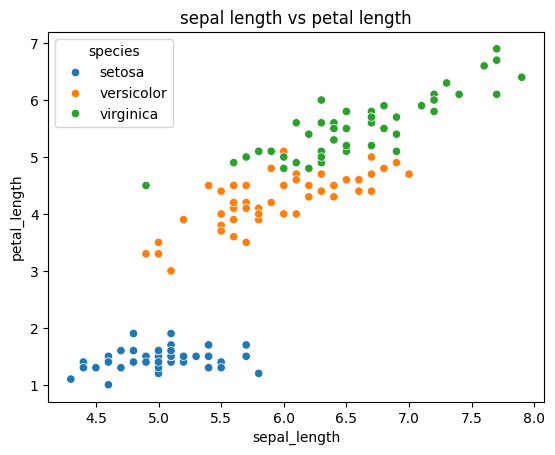

In [ ]:
#scatter plot
sns.scatterplot(
    data = df,
    x="sepal_length",
    y="petal_length",
    hue="species")
plt.title("sepal length vs petal length")
plt.show()

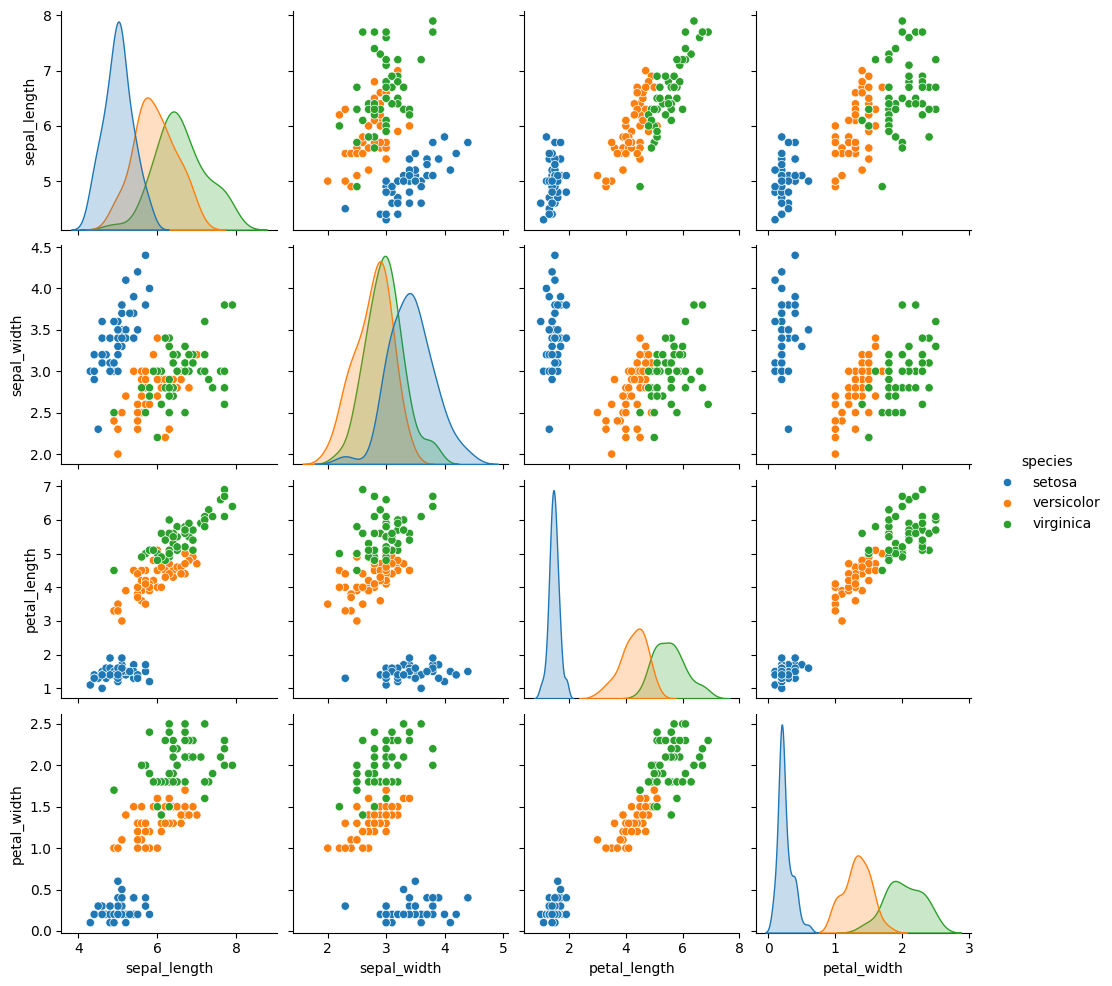

In [ ]:
#pair plot
sns.pairplot(df,hue="species")
plt.show()

correlation matrix:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


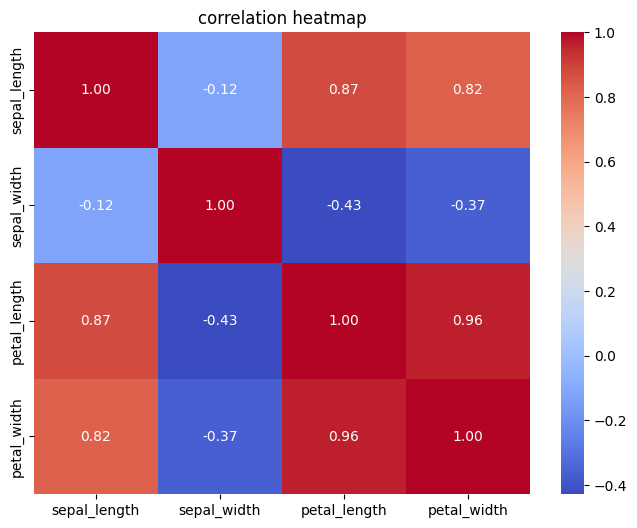

In [ ]:
#correlation heatmap
numeric_df = df.drop(columns=["species"])
corr = numeric_df.corr()

print("correlation matrix:")
print(corr)

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("correlation heatmap")
plt.show()

In [ ]:
#strongest positive and negative pair
pairs = corr.where(
     ~ np.tril(np.ones(corr.shape)).astype(bool)
)